<a href="https://colab.research.google.com/github/CatalinaOrtegha/IA-aumentada-previsi-n-de-atrasos-de-vuelos/blob/main/Ejercicio_optimizacion_aeroportuaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Entendiendo el conjunto de datos

In [29]:
import pandas as pd

In [30]:
url='https://raw.githubusercontent.com/CatalinaOrtegha/IA-aumentada-previsi-n-de-atrasos-de-vuelos/refs/heads/main/flights.csv'

datos=pd.read_csv(url)
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [31]:
datos.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271


In [32]:
datos.describe()

,flight_id,arrival_time,departure_time,day,year,delay
count,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000
mean,15.465135,13.283159,16.480222,182.000000,2016.000000,12.548378
std,8.649646,4.023380,4.143705,105.366769,3.741684,23.125349
min,1.000000,7.065594,10.065594,0.000000,2010.000000,-41.028033
25%,8.000000,8.939996,12.668655,91.000000,2013.000000,-4.412876
50%,15.000000,14.258911,16.376052,182.000000,2016.000000,9.740454
75%,23.000000,16.909690,20.041281,273.000000,2019.000000,27.650853
max,30.000000,19.341235,23.341235,364.000000,2022.000000,125.632352


In [33]:
datos.describe(include='O')

,airline,aircraft_type,schengen,origin
count,71175,71175,71175,71175
unique,3,6,2,10
top,BZ,Airbus A320,schengen,TZF
freq,47598,30778,42569,14162


# Análisis gráfico del conjunto de datos

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt


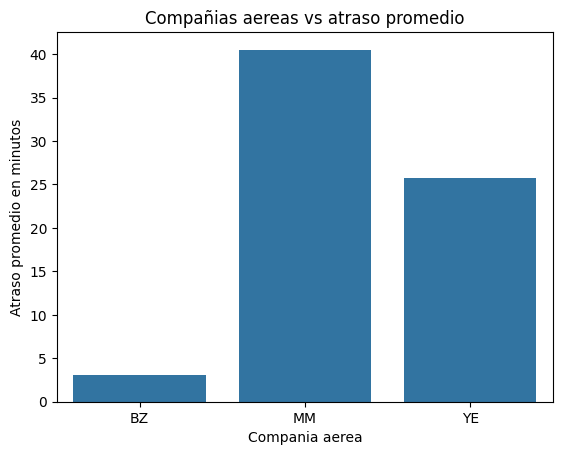

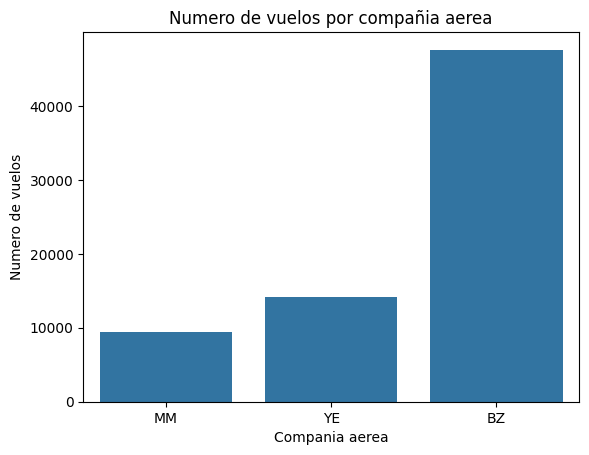

In [35]:
avg_delay = datos.groupby('airline')['delay'].mean().reset_index()
sns.barplot(x='airline', y='delay', data=avg_delay)
plt.title('Compañias aereas vs atraso promedio')
plt.xlabel('Compania aerea')
plt.ylabel('Atraso promedio en minutos')
plt.show()

sns.countplot(data=datos, x='airline')
plt.title('Numero de vuelos por compañia aerea')
plt.xlabel('Compania aerea')
plt.ylabel('Numero de vuelos')
plt.show()

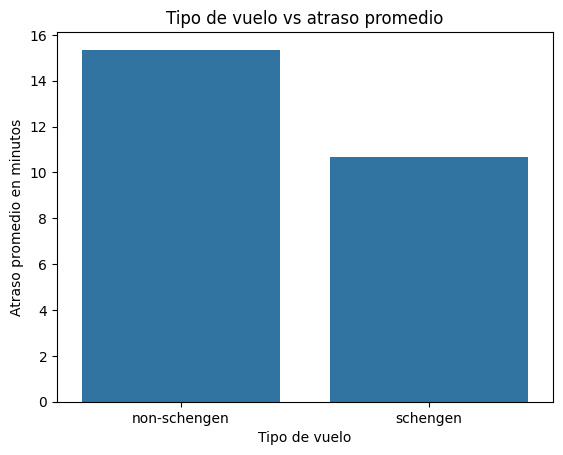

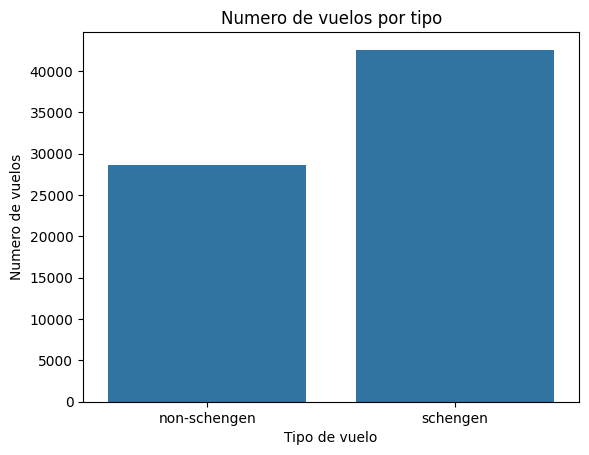

In [36]:
avg_delay = datos.groupby('schengen')['delay'].mean().reset_index()
sns.barplot(x='schengen', y='delay', data=avg_delay)
plt.title('Tipo de vuelo vs atraso promedio')
plt.xlabel('Tipo de vuelo')
plt.ylabel('Atraso promedio en minutos')
plt.show()

sns.countplot(data=datos, x='schengen')
plt.title('Numero de vuelos por tipo')
plt.xlabel('Tipo de vuelo')
plt.ylabel('Numero de vuelos')
plt.show()

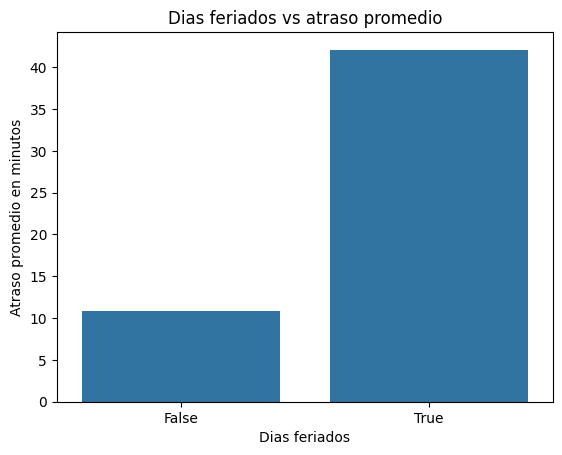

In [37]:
avg_delay = datos.groupby('is_holiday')['delay'].mean().reset_index()
sns.barplot(x='is_holiday', y='delay', data=avg_delay)
plt.title('Dias feriados vs atraso promedio')
plt.xlabel('Dias feriados')
plt.ylabel('Atraso promedio en minutos')
plt.show()

In [38]:
datos['aircraft_type'].value_counts().index

Index(['Airbus A320', 'Airbus A330', 'Boeing 787', 'Embraer E175',
       'Boeing 737', 'Boeing 777'],
      dtype='object', name='aircraft_type')

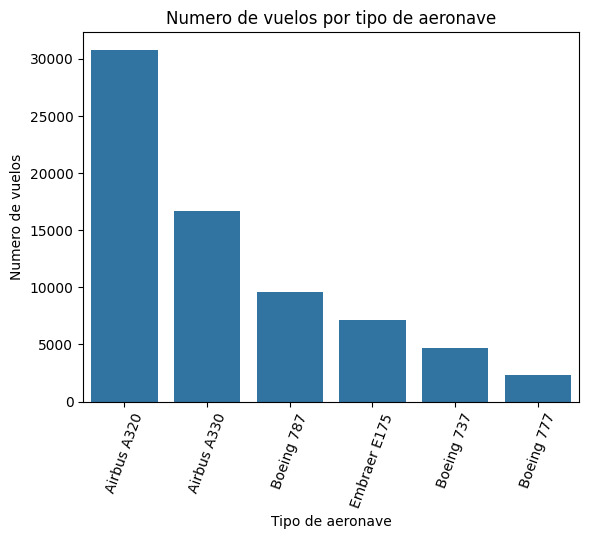

In [39]:
order = datos['aircraft_type'].value_counts().index

sns.countplot(data=datos, x='aircraft_type', order=order)
plt.title('Numero de vuelos por tipo de aeronave')
plt.xticks(rotation=70)
plt.xlabel('Tipo de aeronave')
plt.ylabel('Numero de vuelos')
plt.show()

# Analizando la distribución de los datos

In [40]:
#Freedman Diaconis (Tamaño de los bins)

In [41]:
import numpy as np

def ancho_bin (df,columna):
  q75,q25 = np.percentile(df[columna],[75,25])
  iqr = q75 - q25
  ancho = 2 * iqr * np.power(len(df[columna]),-1/3)
  return ancho


<Axes: xlabel='arrival_time', ylabel='Count'>

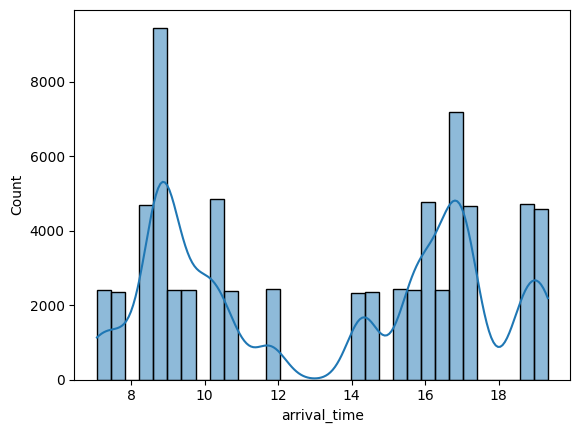

In [42]:
binwidth = ancho_bin(datos,'arrival_time')
sns.histplot(data=datos, x='arrival_time', kde=True, binwidth=binwidth)


<Axes: xlabel='departure_time', ylabel='Count'>

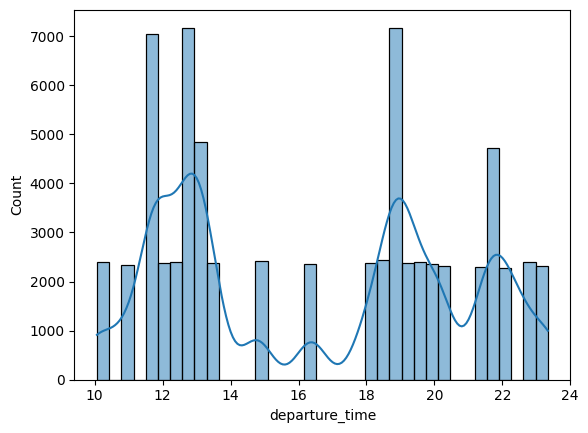

In [43]:
binwidth = ancho_bin(datos,'departure_time')
sns.histplot(data=datos, x='departure_time', kde=True, binwidth=binwidth)

In [44]:
atraso_promedio = datos['delay'].mean()
atraso_mediana = datos['delay'].median()

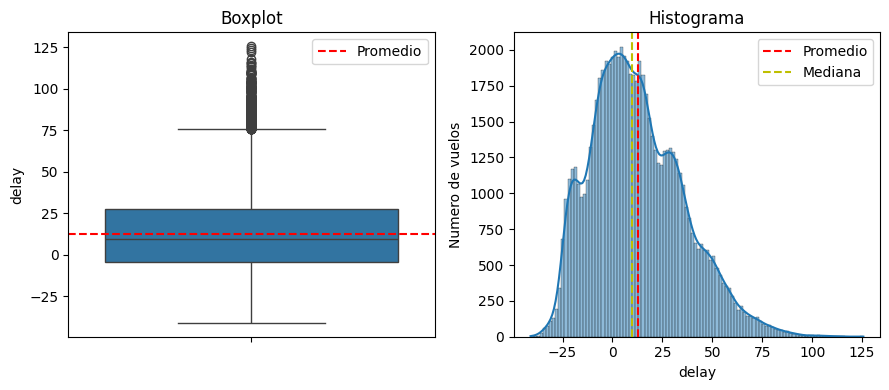

In [45]:
fig, ax = plt.subplots(1,2, figsize=(9, 4))
sns.boxplot(data=datos, y='delay', ax=ax[0])
ax[0].set_title('Boxplot')
ax[0].axhline(y=atraso_promedio, color='r', linestyle='--', label = 'Promedio')
ax[0].legend()

binwidth= ancho_bin(datos,'delay')
sns.histplot(data=datos, x='delay', ax=ax[1], kde=True, binwidth=binwidth)
plt.ylabel('Numero de vuelos')
plt.grid(False)
ax[1].set_title('Histograma')
ax[1].axvline(x=atraso_promedio, color='r', linestyle='--', label = 'Promedio')
ax[1].axvline(x=atraso_mediana, color='y', linestyle='--', label = 'Mediana')
ax[1].legend()

plt.tight_layout()
plt.show()


#Creando nuevas columnas

In [46]:
datos.columns


Index(['flight_id', 'airline', 'aircraft_type', 'schengen', 'origin',
       'arrival_time', 'departure_time', 'day', 'year', 'is_holiday', 'delay'],
      dtype='object')

In [47]:
datos['date'] = datos['year'].astype(str) + '-' + (datos['day']+1).astype(str)
datos['date'] = pd.to_datetime(datos['date'], format='%Y-%j')
datos.tail(2)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date
71173,5,BZ,Airbus A320,schengen,ZQO,9.344097,12.344097,364,2022,True,56.758844,2022-12-31
71174,29,BZ,Boeing 737,schengen,ZQO,8.591208,11.591208,364,2022,True,41.401648,2022-12-31


In [48]:
datos['is_weekend'] = datos['date'].dt.weekday.isin([5,6])
datos['day_name'] = datos['date'].dt.day_name()
datos.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981,2010-01-01,False,Friday
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609,2010-01-01,False,Friday
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305,2010-01-01,False,Friday
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491,2010-01-01,False,Friday
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271,2010-01-01,False,Friday


# Feature Encoding

In [49]:
import warnings
warnings.filterwarnings('ignore')

In [50]:
datos['schengen'] = datos['schengen'].replace({'non-schengen':0,'schengen':1})
datos['is_holiday'] = datos['is_holiday'].replace({False:0,True:1})
datos['is_weekend'] = datos['is_weekend'].replace({False:0,True:1})
datos.sample(3)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
55093,17,BZ,Airbus A330,0,CNU,16.718722,21.718722,22,2020,0,-4.873093,2020-01-23,0,Thursday
37584,1,BZ,Airbus A320,0,CNU,15.496519,18.496519,315,2016,0,23.539960,2016-11-11,0,Friday
46386,23,YE,Embraer E175,1,TCY,18.801235,21.801235,172,2018,0,11.322024,2018-06-22,0,Friday


In [51]:
categoricas = ['airline','aircraft_type','origin','day_name']
datos_codificados = pd.get_dummies(data=datos, columns=categoricas, dtype=int)
datos_codificados.sample(5)

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
53760,6,1,17.033688,19.033688,299,2019,0,26.243228,2019-10-27,1,...,0,0,0,0,0,0,1,0,0,0
14504,18,1,14.258911,20.258911,236,2012,0,-10.517749,2012-08-24,0,...,0,1,0,1,0,0,0,0,0,0
26060,3,1,18.635384,22.635384,277,2014,0,-22.164694,2014-10-05,1,...,0,1,0,0,0,0,1,0,0,0
57551,8,1,15.729617,18.729617,186,2020,0,-3.658463,2020-07-05,1,...,0,0,1,0,0,0,1,0,0,0
36193,7,1,8.564949,13.564949,222,2016,0,14.434349,2016-08-10,0,...,0,1,0,0,0,0,0,0,0,1


#Limpiando los datos

In [53]:
datos_codificados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   flight_id                   71175 non-null  int64         
 1   schengen                    71175 non-null  int64         
 2   arrival_time                71175 non-null  float64       
 3   departure_time              71175 non-null  float64       
 4   day                         71175 non-null  int64         
 5   year                        71175 non-null  int64         
 6   is_holiday                  71175 non-null  int64         
 7   delay                       71175 non-null  float64       
 8   date                        71175 non-null  datetime64[ns]
 9   is_weekend                  71175 non-null  int64         
 10  airline_BZ                  71175 non-null  int64         
 11  airline_MM                  71175 non-null  int64     

In [52]:
datos[['arrival_time','departure_time']].corr()

,arrival_time,departure_time
arrival_time,1.000000,0.973797
departure_time,0.973797,1.000000


In [54]:
df =  datos_codificados.drop(columns=['flight_id','departure_time','day','year','date'])
df.sample(10)

,schengen,arrival_time,is_holiday,delay,is_weekend,airline_BZ,airline_MM,airline_YE,aircraft_type_Airbus A320,aircraft_type_Airbus A330,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
35849,0,16.718722,0,-8.564872,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
63039,0,16.571894,0,-4.584572,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
7324,0,16.718722,0,-3.342300,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
14272,1,14.376052,0,-6.321611,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
17962,0,8.939996,0,44.464156,1,0,0,1,1,0,...,1,0,0,0,0,1,0,0,0,0
18691,1,9.344097,0,-6.020780,1,1,0,0,1,0,...,0,0,1,0,0,1,0,0,0,0
16002,0,16.571894,0,31.839569,1,1,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
37393,0,8.939996,0,18.657227,1,0,0,1,1,0,...,1,0,0,0,0,1,0,0,0,0
33660,0,16.571894,0,-5.494211,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
23170,1,18.801235,0,41.334445,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,1
